<a href="https://colab.research.google.com/github/Sezikeye/Assignment-AI/blob/main/Assignment_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text processing
from sklearn.feature_extraction.text import TfidfVectorizer

# Model + evaluation
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# for preprocessing text
import re
from sklearn.pipeline import Pipeline


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [6]:

df = pd.read_csv('/content/drive/MyDrive/amazon_alexa.tsv', sep='\t')

print(df.head())


   rating       date         variation  \
0       5  31-Jul-18  Charcoal Fabric    
1       5  31-Jul-18  Charcoal Fabric    
2       4  31-Jul-18    Walnut Finish    
3       5  31-Jul-18  Charcoal Fabric    
4       5  31-Jul-18  Charcoal Fabric    

                                    verified_reviews  feedback  
0                                      Love my Echo!         1  
1                                          Loved it!         1  
2  Sometimes while playing a game, you can answer...         1  
3  I have had a lot of fun with this thing. My 4 ...         1  
4                                              Music         1  


In [7]:
# handling  missing values
print(df.isnull().sum())


rating              0
date                0
variation           0
verified_reviews    1
feedback            0
dtype: int64


In [9]:
df = df.dropna(subset=['verified_reviews'])
print(df.isnull().sum())



rating              0
date                0
variation           0
verified_reviews    0
feedback            0
dtype: int64


In [11]:
# we check categorical columns
print(df.shape)
print(df.columns)
print(df['feedback'].value_counts())




(3149, 5)
Index(['rating', 'date', 'variation', 'verified_reviews', 'feedback'], dtype='object')
feedback
1    2893
0     256
Name: count, dtype: int64


In [12]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    text = text.strip()
    return text

df['cleaned_review'] = df['verified_reviews'].apply(clean_text)


In [13]:
# we drop columns date and rating
df = df.drop(['date', 'rating'], axis=1)


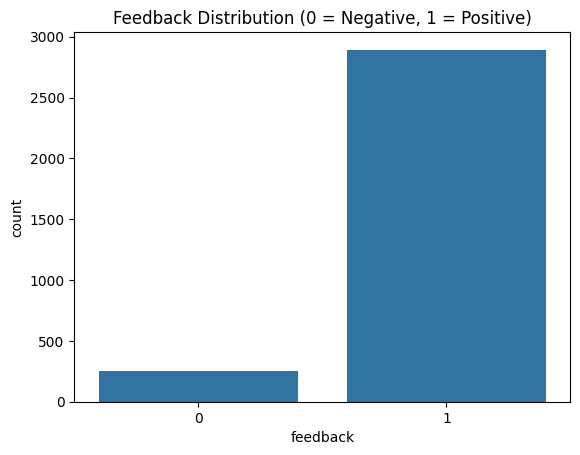

In [14]:
#Visualize Feedback Distribution (Count Plot)
sns.countplot(data=df, x='feedback')
plt.title("Feedback Distribution (0 = Negative, 1 = Positive)")
plt.show()

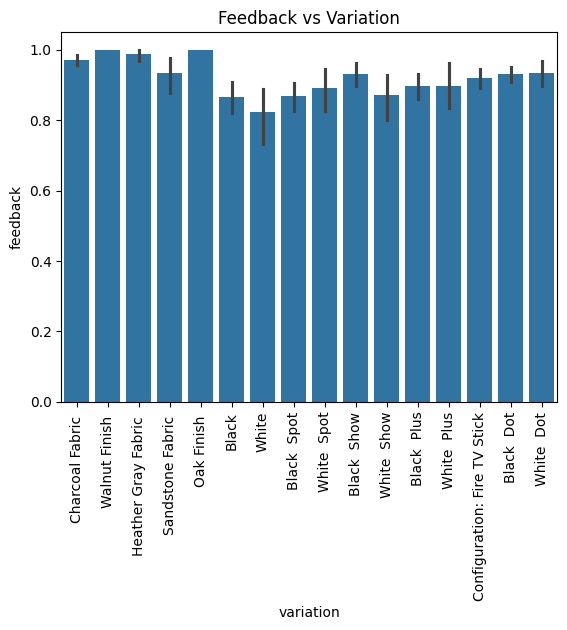

In [15]:
#Bar Plot: Feedback vs Variation
sns.barplot(data=df, x='variation', y='feedback')
plt.title("Feedback vs Variation")
plt.xticks(rotation=90)
plt.show()


In [17]:

# Step 1: One-hot encode the 'variation' column
variation_dummies = pd.get_dummies(df['variation'], prefix='variation')

# Step 2: Concatenate encoded columns back to original dataframe
df = pd.concat([df, variation_dummies], axis=1)

# Step 3: Drop the original 'variation' column
df = df.drop('variation', axis=1)



In [18]:
#TOKENIZATION
from sklearn.feature_extraction.text import CountVectorizer

# Initialize the vectorizer
vectorizer = CountVectorizer(stop_words='english')

# Fit and transform the text data
X = vectorizer.fit_transform(df['verified_reviews'])

# Initialize the vectorizer
vectorizer = CountVectorizer(stop_words='english')

# Fit and transform the text data
X = vectorizer.fit_transform(df['verified_reviews'])

In [20]:

bow_df = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out()
)

bow_df.head()


,00,000,07,10,100,100x,11,1100sf,12,129,...,youtube,yr,yrs,yup,zero,zigbee,zonked,zzzz,zzzzzzz,útil
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [24]:
# SPLING DATA  INTO  TRAINING TESTS

# Features (X) and target (y)
X = bow_df # Use the vectorized features
y = df['feedback']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [25]:
#Training the model
# Initialize model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [29]:
# Prediction
y_pred = rf_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)


Accuracy: 93.02%
[[ 22  41]
 [  3 564]]


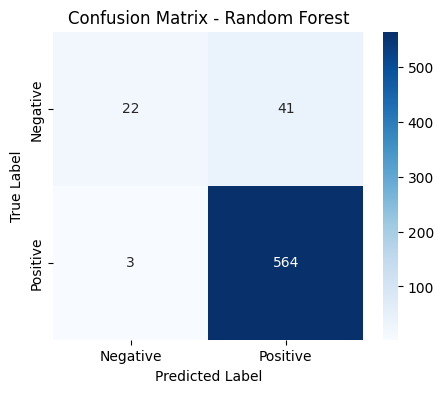

In [30]:
#confusion matrix visualization

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Random Forest")

plt.show()


In [31]:
# Clasification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.35      0.50        63
           1       0.93      0.99      0.96       567

    accuracy                           0.93       630
   macro avg       0.91      0.67      0.73       630
weighted avg       0.93      0.93      0.92       630

